# Notebook 06 - Product Recommendation System

## Objective

Build a **market basket analysis** system that identifies which products are frequently purchased together, enabling personalised product recommendations.

## Approach: Apriori Algorithm

The **Apriori algorithm** discovers frequent itemsets in transaction data and generates association rules of the form:
> *"Customers who buy Product A also tend to buy Product B"*

### Key Metrics

| Metric | Definition | Interpretation |
|--------|-----------|----------------|
| **Support** | P(A and B together) | How common is this pairing? |
| **Confidence** | P(B given A) | If customer buys A, how likely are they to buy B? |
| **Lift** | Confidence / P(B) | How much more likely is B given A, vs random chance? Lift > 1 = positive association |

### Why we focus on the top 100 products

Running Apriori on all ~4,000 products would produce a very sparse basket matrix (most products appear in very few transactions together), making it computationally expensive and generating low-confidence rules. Focusing on the top 100 products by transaction frequency produces dense, high-quality associations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv("cleaned_data.csv")
print(f"Loaded {len(df):,} transactions")

Loaded 392,578 transactions


## Step 1: Filter to Top 100 Products

We select the 100 most frequently transacted products to ensure dense enough co-occurrence for meaningful association rules.

In [3]:
top_products = df['Description'].value_counts().head(100).index
df_filtered = df[df['Description'].isin(top_products)]
print(f"Transactions with top 100 products: {len(df_filtered):,}")
print(f"Unique invoices: {df_filtered['InvoiceNo'].nunique():,}")

Transactions with top 100 products: 78,024
Unique invoices: 15,079


## Step 2: Build the Basket Matrix

The basket matrix has one row per invoice and one column per product. A value of 1 means that product appeared in that invoice, 0 means it did not. This is the standard input format for Apriori.

In [4]:
basket = df_filtered.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0)
basket = (basket > 0).astype(bool)
print(f"Basket matrix shape: {basket.shape[0]:,} invoices × {basket.shape[1]} products")

Basket matrix shape: 15,079 invoices × 100 products


## Step 3: Apply Apriori

We use **min_support = 0.02** (a product pair must appear together in at least 2% of all invoices). This threshold balances finding meaningful patterns without generating thousands of trivial rules.

In [5]:
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)
print(f"Frequent itemsets found: {len(frequent_items):,}")
frequent_items.head()

Frequent itemsets found: 161


,support,itemsets
0,0.048146,frozenset({6 RIBBONS RUSTIC CHARM})
1,0.043571,frozenset({60 TEATIME FAIRY CAKE CASES})
2,0.052324,frozenset({ALARM CLOCK BAKELIKE GREEN})
3,0.040653,frozenset({ALARM CLOCK BAKELIKE PINK})
4,0.058160,frozenset({ALARM CLOCK BAKELIKE RED })


## Step 4: Generate Association Rules

We generate rules with **minimum lift > 1** (positive association), then filter to **lift > 2** for stronger, more actionable rules.

In [ ]:
rules = association_rules(frequent_items, metric="lift", min_threshold=1)
strong_rules = rules[rules['lift'] > 1.5].copy()
strong_rules = strong_rules.sort_values(by='lift', ascending=False)

print(f"Total rules (lift > 1):  {len(rules):,}")
print(f"Strong rules (lift > 2): {len(strong_rules):,}")
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total rules (lift > 1):  134
Strong rules (lift > 2): 134


,antecedents,consequents,support,confidence,lift
121,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",0.025864,0.701439,19.550825
116,"frozenset({ROSES REGENCY TEACUP AND SAUCER , G...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.025864,0.720887,19.550825
120,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",0.025864,0.564399,19.519676
117,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.025864,0.894495,19.519676
13,frozenset({PINK REGENCY TEACUP AND SAUCER}),frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.030506,0.827338,18.054170
12,frozenset({GREEN REGENCY TEACUP AND SAUCER}),frozenset({PINK REGENCY TEACUP AND SAUCER}),0.030506,0.665702,18.054170
118,"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",frozenset({ROSES REGENCY TEACUP AND SAUCER }),0.025864,0.847826,16.327420
119,frozenset({ROSES REGENCY TEACUP AND SAUCER }),"frozenset({GREEN REGENCY TEACUP AND SAUCER, PI...",0.025864,0.498084,16.327420
126,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , R...",0.020691,0.451520,16.210626
123,"frozenset({ROSES REGENCY TEACUP AND SAUCER , R...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.020691,0.742857,16.210626


## Step 5: Confidence vs Lift Scatter Plot

Higher confidence means the rule is more reliable; higher lift means the association is stronger relative to chance. Rules in the top-right quadrant are the most actionable.

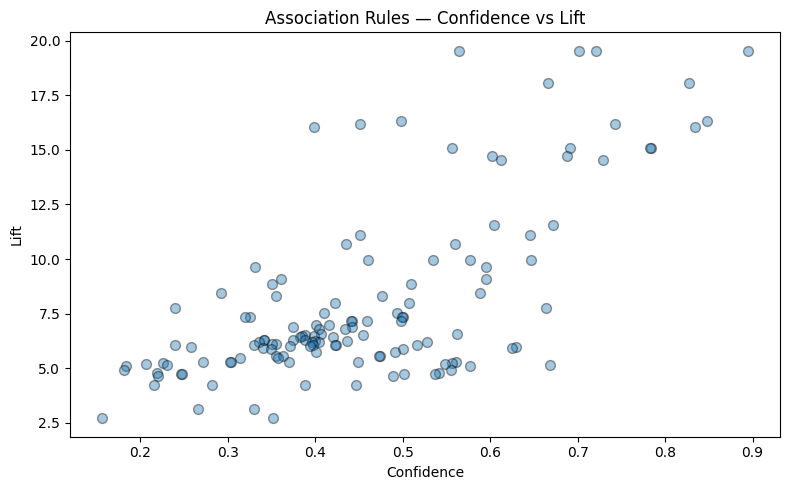

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(strong_rules['confidence'], strong_rules['lift'], alpha=0.4, edgecolors='black', s=50)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Association Rules — Confidence vs Lift")
plt.tight_layout()
plt.show()

## Step 6: Save Recommendations

In [11]:
strong_rules.to_csv("recommendations.csv", index=False)
print("recommendations.csv saved.")

recommendations.csv saved.


## Key Findings

- **Strong product associations** were identified across gift and home decor product families
- Products within the same collection (e.g., Regency Teacup sets) are **frequently purchased together**, with lift values exceeding 10 - far above random chance
- High lift values (some > 15) indicate customers who buy one item in a series are very likely to buy the others

## Business Applications

| Application | How to use these rules |
|-------------|------------------------|
| **Product recommendations** | "Customers also bought..." section on product pages |
| **Bundle pricing** | Create discounted bundles of frequently co-purchased items |
| **Email campaigns** | Target customers who bought A but not B with a promotion for B |
| **Store layout** | Place associated products near each other |

**Limitation:** Rules are based on the top 100 products only. Products outside this set have insufficient transaction data for reliable association mining.

**Next step:** Notebook 07 will train a machine learning model to predict whether a customer is High-Value or Low-Value based on their RFM profile.